In [1]:
import pandas as pd
import numpy as np
 
np.random.seed(1)
ages = np.random.randint(20, 60, 19).tolist() + [95]           # 95 is an outlier
incomes = np.random.randint(35000, 90000, 19).tolist() + [820000]  # matching outlier
genders = np.random.choice(['Male', 'Female'], 20).tolist()
educations = np.random.choice(
    ['High School', 'Bachelors', 'Masters', 'PhD'], 20).tolist()
cities = np.random.choice(['Karachi', 'Lahore', 'Islamabad'], 20).tolist()
purchased = np.random.choice([0, 1], 20, p=[0.3, 0.7]).tolist()
 
customers = pd.DataFrame({
    'Age': ages, 'Income': incomes, 'Gender': genders,
    'Education': educations, 'City': cities, 'Purchased': purchased
})
print(customers.head())


   Age  Income  Gender    Education       City  Purchased
0   57   43444  Female          PhD  Islamabad          0
1   32   54946  Female  High School     Lahore          1
2   28   72532    Male  High School    Karachi          1
3   29   57926    Male    Bachelors  Islamabad          1
4   31   84714  Female          PhD     Lahore          1


In [2]:
from scipy import stats
 
print('Mean Age:', customers['Age'].mean())
print('Trimmed Mean Age:', stats.trim_mean(customers['Age'], 0.1))
print('Median Age:', customers['Age'].median())
 
print('Mean Income:', customers['Income'].mean())
print('Median Income:', customers['Income'].median())


Mean Age: 37.25
Trimmed Mean Age: 34.5
Median Age: 32.0
Mean Income: 103251.55
Median Income: 67879.0


In [12]:
print('Std Dev:', customers['Income'].std())
print('Variance:', customers['Income'].var())
 
q1 = customers['Income'].quantile(0.25)
q3 = customers['Income'].quantile(0.75)
print('IQR:', q3 - q1)
 
from statsmodels import robust
print('MAD:', robust.scale.mad(customers['Income']))


Std Dev: 169232.7155986457
Variance: 28639712028.8921
IQR: 18236.25


ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
import pandas as pd

customers = pd.DataFrame({
    'Customer_ID': ['C001', 'C002', 'C003', 'C004', 'C005'],
    'Name': ['Ali', 'Sara', 'Ahmed', 'Ayesha', 'Usman'],
    'Age': [25, 32, 28, 41, 35],
    'Gender': ['Male', 'Female', 'Male', 'Female', 'Male'],
    'Education': ["Bachelor's", "Master's", "Bachelor's", "PhD", "Master's"],
    'Income': [50000, 75000, 60000, 120000, 90000],
    'City': ['Khairpur', 'Sukkur', 'Larkana', 'Khairpur', 'Sukkur'],
    'Satisfaction': [4, 5, 3, 5, 4],
    'Purchased': ['Yes', 'Yes', 'No', 'Yes', 'No']
})

customers

,Customer_ID,Name,Age,Gender,Education,Income,City,Satisfaction,Purchased
0,C001,Ali,25,Male,Bachelor's,50000,Khairpur,4,Yes
1,C002,Sara,32,Female,Master's,75000,Sukkur,5,Yes
2,C003,Ahmed,28,Male,Bachelor's,60000,Larkana,3,No
3,C004,Ayesha,41,Female,PhD,120000,Khairpur,5,Yes
4,C005,Usman,35,Male,Master's,90000,Sukkur,4,No


In [ ]:
import pandas as pd
from scipy.stats import trim_mean

income = customers['Income']

# Mean
mean = income.mean()

# 10% Trimmed Mean
trimmed_mean = trim_mean(income, proportiontocut=0.10)

# Median
median = income.median()

# Standard Deviation
std = income.std()

# IQR
q1 = income.quantile(0.25)
q3 = income.quantile(0.75)
iqr = q3 - q1

print("Mean:", mean)
print("Trimmed Mean:", trimmed_mean)
print("Median:", median)
print("Standard Deviation:", std)
print("IQR:", iqr)

Mean: 79000.0
Trimmed Mean: 79000.0
Median: 75000.0
Standard Deviation: 27477.263328068173
IQR: 30000.0


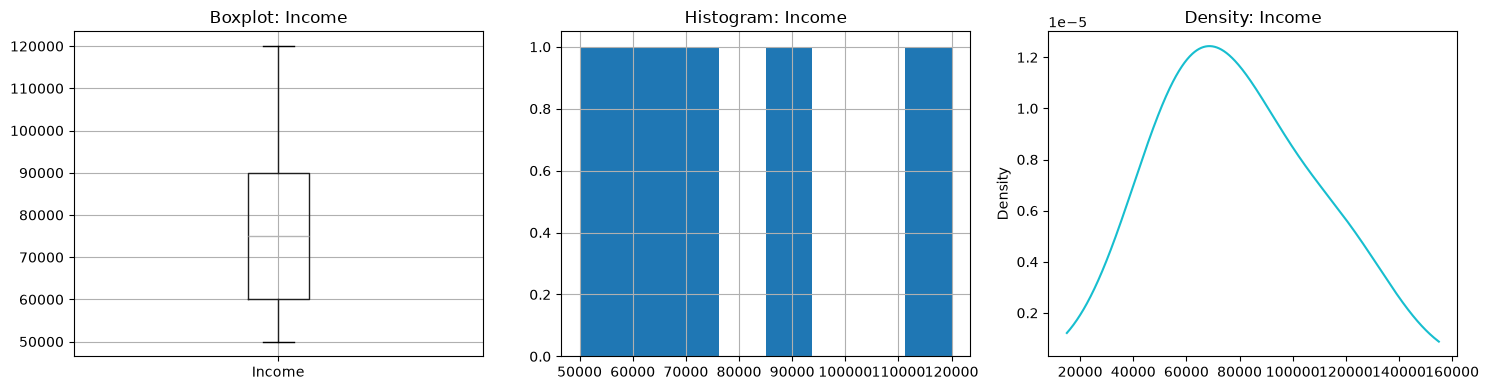

In [15]:
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
customers.boxplot(column='Income', ax=axes[0])
axes[0].set_title('Boxplot: Income')
 
customers['Income'].hist(bins=8, ax=axes[1], color='tab:blue')
axes[1].set_title('Histogram: Income')
 
customers['Income'].plot(kind='density', ax=axes[2], color='tab:cyan')
axes[2].set_title('Density: Income')
 
plt.tight_layout()
plt.show()


Mode: Class 1

Proportions:
target
Class 1    0.398876
Class 0    0.331461
Class 2    0.269663
Name: proportion, dtype: float64


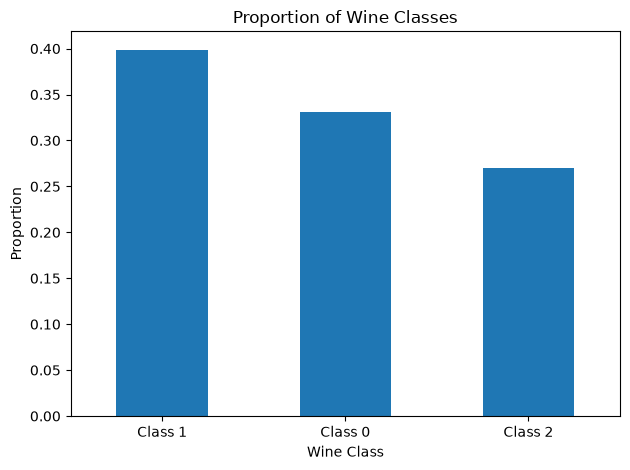

In [1]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
wine = load_wine()

# Create DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add categorical target column
df["target"] = wine.target

# Convert target numbers to category names
df["target"] = df["target"].map({
    0: "Class 0",
    1: "Class 1",
    2: "Class 2"
})

# 1. Calculate the mode
mode = df["target"].mode()[0]

# 2. Calculate proportions
proportions = df["target"].value_counts(normalize=True)

print("Mode:", mode)
print("\nProportions:")
print(proportions)

# 3. Bar chart
proportions.plot(kind="bar")

plt.title("Proportion of Wine Classes")
plt.xlabel("Wine Class")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

corr_pairs = correlation_matrix.where(
    ~np.eye(correlation_matrix.shape[0], dtype=bool)
).stack()

Correlation Matrix:
                  alcohol  malic_acid  color_intensity   proline
alcohol          1.000000    0.094397         0.546364  0.643720
malic_acid       0.094397    1.000000         0.248985 -0.192011
color_intensity  0.546364    0.248985         1.000000  0.316100
proline          0.643720   -0.192011         0.316100  1.000000

Strongest Positive Pair:
('alcohol', 'proline') = 0.6437200371782134

Strongest Negative Pair:
('malic_acid', 'proline') = -0.19201056463400906


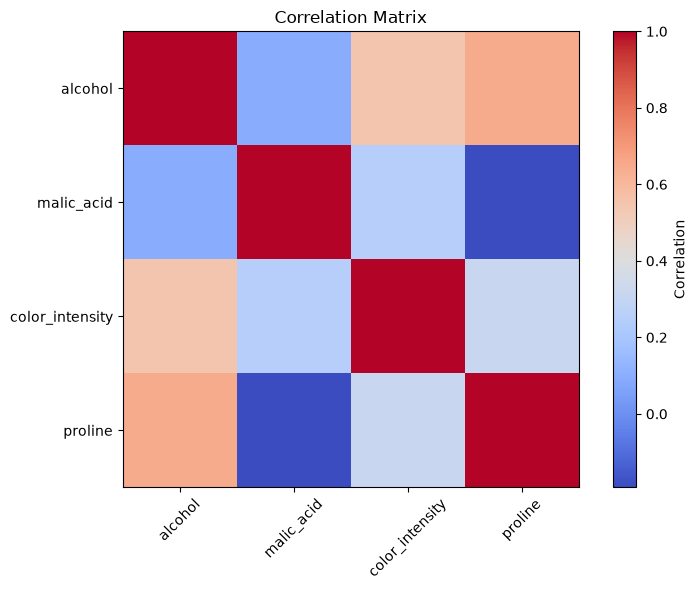

In [9]:
from sklearn.datasets import load_wine
import pandas as pd
import matplotlib.pyplot as plt

# Load the Wine dataset
wine = load_wine()

# Create DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Select at least 3 numeric columns
selected_columns = [
    "alcohol",
    "malic_acid",
    "color_intensity",
    "proline"
]

data = df[selected_columns]

# Calculate correlation matrix
correlation_matrix = data.corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Find strongest positive and negative pairs
corr_pairs = correlation_matrix.where(
    ~np.eye(correlation_matrix.shape[0], dtype=bool)
).stack()

strongest_positive = corr_pairs.idxmax()
strongest_negative = corr_pairs.idxmin()

print("\nStrongest Positive Pair:")
print(strongest_positive, "=", corr_pairs.max())

print("\nStrongest Negative Pair:")
print(strongest_negative, "=", corr_pairs.min())

# Visualize correlation matrix
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Correlation")
plt.xticks(range(len(selected_columns)), selected_columns, rotation=45)
plt.yticks(range(len(selected_columns)), selected_columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# Task 4: Categorical Data

For this task, I use the Wine dataset from sklearn.datasets.
The target variable represents three different wine classes:
Class 0, Class 1, and Class 2.

I will calculate the mode and proportions of the categorical
variable and visualize the proportions using a bar chart.

In [11]:
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np

# Load the Wine dataset
wine = load_wine()

# Create DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Select numeric column
data = df["alcohol"]

# Set seed so results are reproducible
np.random.seed(42)

# Number of bootstrap resamples
n_bootstrap = 1000

# Store bootstrap means
bootstrap_means = []

# Bootstrap sampling
for i in range(n_bootstrap):
    sample = np.random.choice(
        data,
        size=len(data),
        replace=True
    )
    
    bootstrap_means.append(np.mean(sample))

# Convert to NumPy array
bootstrap_means = np.array(bootstrap_means)

# Calculate standard error
standard_error = np.std(bootstrap_means, ddof=1)

# Calculate 95% confidence interval
lower = np.percentile(bootstrap_means, 2.5)
upper = np.percentile(bootstrap_means, 97.5)

# Original sample mean
original_mean = np.mean(data)

print("Original Mean:", original_mean)
print("Bootstrap Standard Error:", standard_error)
print("95% Confidence Interval:", (lower, upper))

Original Mean: 13.00061797752809
Bootstrap Standard Error: 0.058556189740918564
95% Confidence Interval: (np.float64(12.88863061797753), np.float64(13.115529494382026))


# Task 5: Correlation

For this task, I use four numeric columns from the Wine dataset:
Alcohol, Malic Acid, Color Intensity, and Proline.

I will calculate a correlation matrix and identify the strongest
positive and strongest negative correlation pairs.

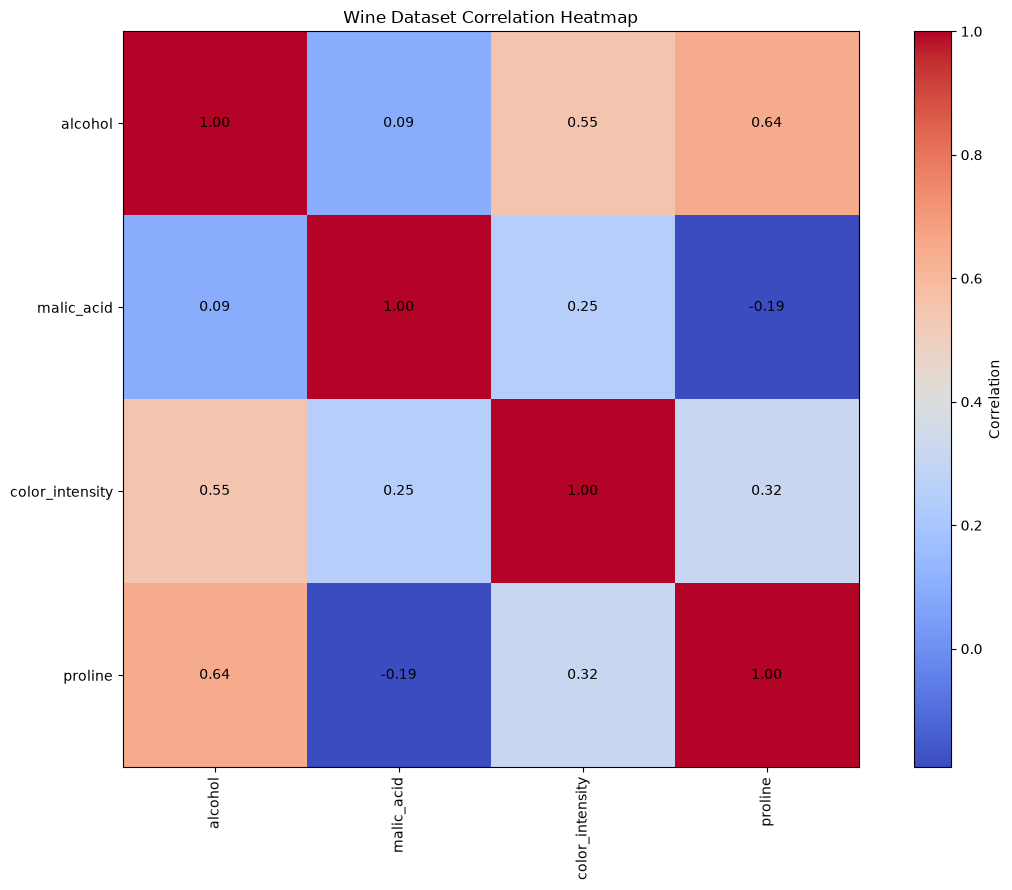

In [14]:
plt.figure(figsize=(12, 9))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add correlation values
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Wine Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()